# The plan
## Data
* read only lines with eccentricity data
* split into two catalogues orb6 and sb9
## Binary Generator
* Draw M1
* Draw binary yes/no
* Draw P
* Draw q
* Draw e
* Draw orientation
* Draw phase
## Apply observation constraints


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


In [7]:


df = pd.read_csv(r'DATA/RAW/reduced_raw_data.csv')

# Exclude rows with no eccentricity entry
df_clean = df[df["e"].notna()].copy()

# Function to check if a catalogue string contains a given catalogue name
def contains_catalogue(cat_string, target):
    if pd.isna(cat_string):
        return False
    entries = [c.strip() for c in str(cat_string).split(";")]
    return target in entries

# Split into OB6 and SB9 dataframes
df_ORB6 = df_clean[df_clean["catalogue"].apply(lambda x: contains_catalogue(x, "ORB6"))].copy()
df_SB9 = df_clean[df_clean["catalogue"].apply(lambda x: contains_catalogue(x, "SB9"))].copy()

# Extract relevant columns
cols = ["system_id", "catalogue", "e", "q", "period", "a", "i"]

df_ORB6 = df_OB6[cols].reset_index(drop=True)
df_SB9 = df_SB9[cols].reset_index(drop=True)

print(f"Total rows with eccentricity: {len(df_clean)}")
print(f"ORB6 entries: {len(df_OB6)}")
print(f"SB9 entries: {len(df_SB9)}")
print(f"Total - (ORB6+SB9) : {len(df_clean) -(len(df_OB6) + len(df_SB9))}")


Total rows with eccentricity: 4977
ORB6 entries: 2147
SB9 entries: 3111
Total - (ORB6+SB9) : -281


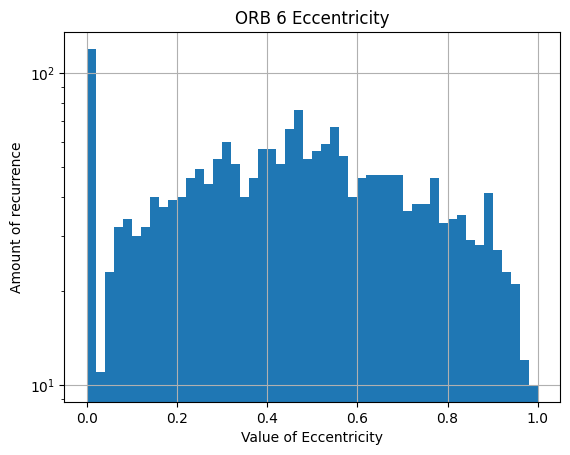

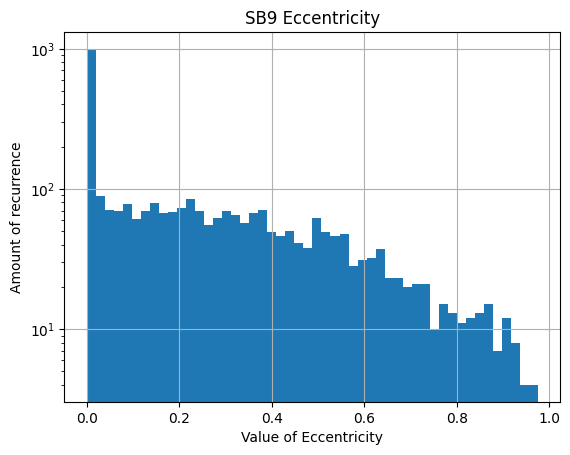

In [11]:
plt.hist(df_ORB6["e"],log=True, bins=50)
plt.xlabel('Value of Eccentricity')
plt.ylabel('Amount of recurrence')
plt.title('ORB 6 Eccentricity')
plt.grid(True)
plt.show()
plt.hist(df_SB9["e"],log=True, bins=50)
plt.xlabel('Value of Eccentricity')
plt.ylabel('Amount of recurrence')
plt.title('SB9 Eccentricity')
plt.grid(True)
plt.show()

C:\Users\eljam\AppData\Local\Temp\ipykernel_16756\1096621222.py:21: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  A = 1.0 / np.trapz(q_norm ** gamma_large, q_norm)


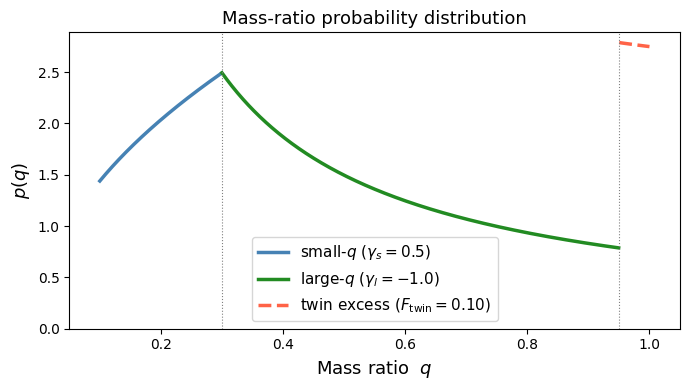

In [12]:
def mass_distribution(q, gamma_small, gamma_large, F_twin):
    """
    Piecewise power-law mass-ratio probability distribution (Moe & Di Stefano).

    Parameters
    ----------
    q            : array-like, mass ratios in [0.1, 1.0]
    gamma_small  : float, power-law slope for q = 0.1–0.3
    gamma_large  : float, power-law slope for q = 0.3–1.0
    F_twin       : float, excess twin fraction for q = 0.95–1.00

    Returns
    -------
    p_q : ndarray, normalised such that Integral of p = 1
    """
    q = np.asarray(q, dtype=float)
    p_q = np.zeros_like(q)

    # --- Normalisation constant A so that ∫₀.₃¹·⁰ q^γ_large dq = 1 ---
    q_norm = np.linspace(0.3, 1.0, 10_000)
    A = 1.0 / np.trapz(q_norm ** gamma_large, q_norm)

    # Twin excess amplitude: redistributes F_twin fraction uniformly over [0.95, 1.00]
    twin_width = 0.05
    twin_amplitude = F_twin / twin_width  # uniform box on [0.95, 1.00]

    # --- Large-q regime (0.3 ≤ q ≤ 1.0) ---
    large = (q >= 0.3) & (q <= 1.0)
    p_q[large] = (1 - F_twin) * A * q[large] ** gamma_large
    twin = (q >= 0.95) & (q <= 1.00)
    p_q[twin] += twin_amplitude

    # --- Small-q regime (0.1 ≤ q < 0.3): power law anchored at q = 0.3 ---
    p_at_03 = (1 - F_twin) * A * 0.3 ** gamma_large
    small = (q >= 0.1) & (q < 0.3)
    p_q[small] = p_at_03 * (q[small] / 0.3) ** gamma_small

    return p_q


# --- Plot ---
q = np.linspace(0.1, 1.0, 1000)
p = mass_distribution(q, gamma_small=0.5, gamma_large=-1.0, F_twin=0.10)

fig, ax = plt.subplots(figsize=(7, 4))

# Colour-coded segments
small_mask = q < 0.3
large_mask = (q >= 0.3) & (q < 0.95)
twin_mask  = q >= 0.95

ax.plot(q[small_mask], p[small_mask], color='steelblue',  lw=2.5, label=r'small-$q$ ($\gamma_s = 0.5$)')
ax.plot(q[large_mask], p[large_mask], color='forestgreen', lw=2.5, label=r'large-$q$ ($\gamma_l = -1.0$)')
ax.plot(q[twin_mask],  p[twin_mask],  color='tomato',      lw=2.5, ls='--', label=r'twin excess ($F_\mathrm{twin} = 0.10$)')

ax.axvline(0.3,  color='gray', lw=0.8, ls=':')
ax.axvline(0.95, color='gray', lw=0.8, ls=':')
ax.set_xlabel('Mass ratio  $q$', fontsize=13)
ax.set_ylabel('$p(q)$', fontsize=13)
ax.set_title('Mass-ratio probability distribution', fontsize=13)
ax.legend(fontsize=11)
ax.set_xlim(0.05, 1.05)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

## Binary Generator
* Draw M1
* Draw binary yes/no
* Draw P
* Draw q
* Draw e
* Draw orientation
* Draw phase

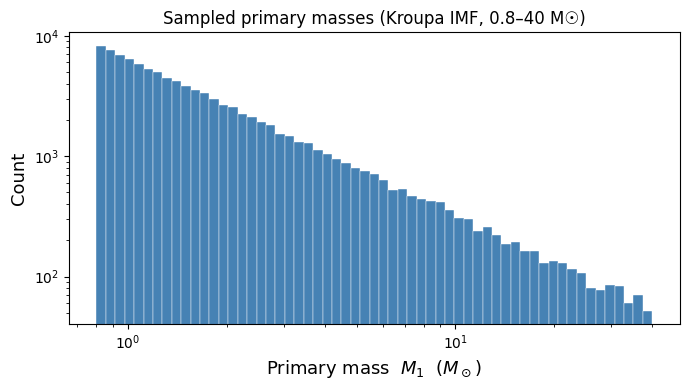

Median M1 = 1.36 M☉


In [14]:
# Draw M1
# use kroupa
import imf
import numpy as np

rng = np.random.default_rng(42)
N_systems = 100_000
def sample_kroupa_imf(n, m_min=0.8, m_max=40.0, seed=None):
    """
    Draw n primary masses from the Kroupa (2001) IMF restricted to [m_min, m_max].
    Restricted sampling is achieved by drawing u uniformly between
    CDF(m_min) and CDF(m_max), then transforming via the PPF.
    """
    rng_loc = np.random.default_rng(seed)
    lo = imf.kroupa.distr.cdf(m_min)
    hi = imf.kroupa.distr.cdf(m_max)
    u  = rng_loc.uniform(lo, hi, n)
    return imf.inverse_imf(u, massfunc=imf.kroupa)

M1 = sample_kroupa_imf(N_systems, seed=42)

fig, ax = plt.subplots(figsize=(7,4))
bins = np.logspace(np.log10(0.8), np.log10(40), 60)
ax.hist(M1, bins=bins, color='steelblue', edgecolor='white', lw=0.3)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel(r'Primary mass  $M_1$  ($M_\odot$)', fontsize=13)
ax.set_ylabel('Count', fontsize=13)
ax.set_title('Sampled primary masses (Kroupa IMF, 0.8–40 M☉)', fontsize=12)
plt.tight_layout(); plt.show()
print(f"Median M1 = {np.median(M1):.2f} M☉")




Total systems:  100,000
Binary systems: 32,236  (32.2%)


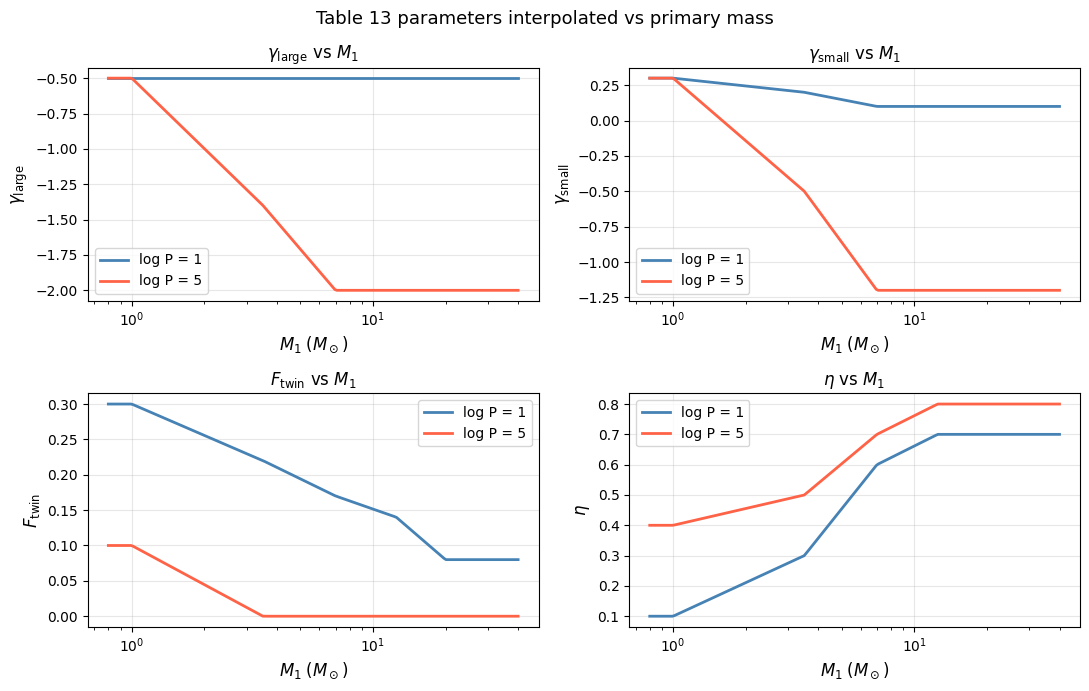

In [19]:
# ── Moe & Di Stefano (2017) Table 13 ─────────────────────────────────────────
# All parameters are stored at the five M1 bin midpoints and the four
# log P nodes tabulated.  Bilinear interpolation is used throughout.

# M1 bin midpoints (solar masses) and their log10 values
_M1_pts = np.array([1.0, 3.5, 7.0, 12.5, 20.0])
_logM1 = np.log10(_M1_pts)

# log P nodes at which the period-dependent parameters are tabulated
_logP_pts = np.array([1.0, 3.0, 5.0, 7.0])

# ── Binary-star fraction  n(n=1; q>0.1)  (Table 13, row 4) ──────────────────
# Only a function of M1 (integrated over all periods)
_fbin = np.array([0.30, 0.37, 0.36, 0.32, 0.21])


def binary_fraction(M1):
    """
    Binary-star fraction n(q>0.1; n=1) interpolated directly from
        Moe & Di Stefano (2017) Table 13.  Flat extrapolation beyond range.
    """
    return np.interp(np.log10(np.asarray(M1, dtype=float)), _logM1, _fbin)


# ── F_twin  (Table 13) ───────────────────────────────────────────────────────
# Shape: (4 logP nodes) x (5 M1 bins)
# Upper-limit entries (<0.03) treated as 0.0
_F_twin_table = np.array([
    [0.30, 0.22, 0.17, 0.14, 0.08],  # log P = 1
    [0.20, 0.10, 0.00, 0.00, 0.00],  # log P = 3
    [0.10, 0.00, 0.00, 0.00, 0.00],  # log P = 5
    [0.00, 0.00, 0.00, 0.00, 0.00],  # log P = 7
])

# ── gamma_large  (Table 13) ──────────────────────────────────────────────────
_gamma_large_table = np.array([
    [-0.5, -0.5, -0.5, -0.5, -0.5],  # log P = 1
    [-0.5, -0.9, -1.7, -1.7, -1.7],  # log P = 3
    [-0.5, -1.4, -2.0, -2.0, -2.0],  # log P = 5
    [-1.1, -2.0, -2.0, -2.0, -2.0],  # log P = 7
])

# ── gamma_small  (Table 13) ──────────────────────────────────────────────────
_gamma_small_table = np.array([
    [0.3, 0.2, 0.1, 0.1, 0.1],  # log P = 1
    [0.3, 0.1, -0.2, -0.2, -0.2],  # log P = 3
    [0.3, -0.5, -1.2, -1.2, -1.2],  # log P = 5
    [0.3, -1.0, -1.5, -1.5, -1.5],  # log P = 7
])

# ── eta  (Table 13) ──────────────────────────────────────────────────────────
# Tabulated at log P = 2 and 4 only; we extend to 1 and 7 by flat extrapolation
_eta_logP_pts = np.array([1.0, 2.0, 4.0, 7.0])
_eta_table = np.array([
    [0.1, 0.3, 0.6, 0.7, 0.7],  # log P = 1  (flat-extrapolated from logP=2)
    [0.1, 0.3, 0.6, 0.7, 0.7],  # log P = 2
    [0.4, 0.5, 0.7, 0.8, 0.8],  # log P = 4
    [0.4, 0.5, 0.7, 0.8, 0.8],  # log P = 7  (flat-extrapolated from logP=4)
])


def _bilinear(table, logP_nodes, logM1_vals, logP_vals):
    """
    Bilinear interpolation in (log P, log M1) from a 2-D table.
    table shape: (n_logP, n_M1)
    Returns 1-D array of length len(logM1_vals).
    """
    logM1_vals = np.asarray(logM1_vals, dtype=float)
    logP_vals = np.asarray(logP_vals, dtype=float)
    out = np.empty(len(logM1_vals))
    for k in range(len(logM1_vals)):
        # interpolate along M1 axis for each bracketing logP row
        row_lo_idx = np.searchsorted(logP_nodes, logP_vals[k], side='right') - 1
        row_lo_idx = np.clip(row_lo_idx, 0, len(logP_nodes) - 2)
        row_hi_idx = row_lo_idx + 1
        v_lo = np.interp(logM1_vals[k], _logM1, table[row_lo_idx])
        v_hi = np.interp(logM1_vals[k], _logM1, table[row_hi_idx])
        # interpolate along logP axis
        lp_lo = logP_nodes[row_lo_idx]
        lp_hi = logP_nodes[row_hi_idx]
        t = (logP_vals[k] - lp_lo) / (lp_hi - lp_lo)
        out[k] = v_lo + t * (v_hi - v_lo)
    return out


def get_gamma_large(M1, logP):
    return _bilinear(_gamma_large_table, _logP_pts,
                     np.log10(M1), np.asarray(logP))


def get_gamma_small(M1, logP):
    return _bilinear(_gamma_small_table, _logP_pts,
                     np.log10(M1), np.asarray(logP))


def get_F_twin(M1, logP):
    return _bilinear(_F_twin_table, _logP_pts,
                     np.log10(M1), np.asarray(logP))


def get_eta(M1, logP):
    return _bilinear(_eta_table, _eta_logP_pts,
                     np.log10(M1), np.asarray(logP))


# ── Apply binary fraction ─────────────────────────────────────────────────────
is_binary = rng.uniform(0, 1, N_systems) < binary_fraction(M1)
M1_bin = M1[is_binary]
print(f"Total systems:  {N_systems:,}")
print(f"Binary systems: {is_binary.sum():,}  ({100 * is_binary.mean():.1f}%)")

# ── Sanity-check: show how each parameter varies with M1 at two logP values ──
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
m_arr = np.logspace(np.log10(0.8), np.log10(40), 200)
colors = ['steelblue', 'tomato']

for ax, func, ylabel, title in zip(
        axes.flat,
        [get_gamma_large, get_gamma_small, get_F_twin, get_eta],
        [r'$\gamma_\mathrm{large}$', r'$\gamma_\mathrm{small}$',
         r'$F_\mathrm{twin}$', r'$\eta$'],
        [r'$\gamma_\mathrm{large}$ vs $M_1$',
         r'$\gamma_\mathrm{small}$ vs $M_1$',
         r'$F_\mathrm{twin}$ vs $M_1$',
         r'$\eta$ vs $M_1$'],
):
    for lp, col in zip([1.0, 5.0], colors):
        ax.semilogx(m_arr, func(m_arr, np.full(len(m_arr), lp)),
                    color=col, lw=2, label=f'log P = {lp:.0f}')
    ax.set_xlabel(r'$M_1\;(M_\odot)$', fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.suptitle('Table 13 parameters interpolated vs primary mass', fontsize=13)
plt.tight_layout()
plt.show()


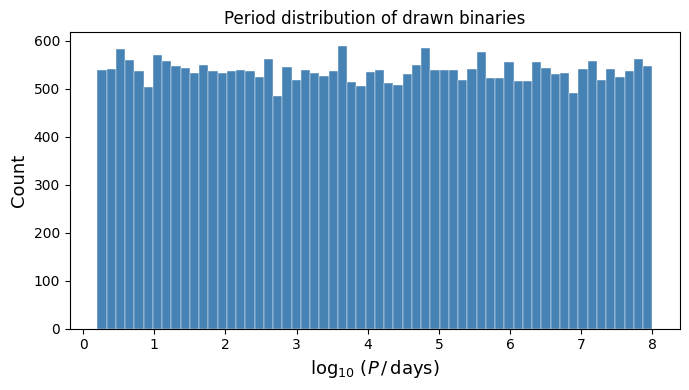

In [20]:
# draw P from uniform log distribution
def sample_period(n, rng_obj, logP_min=0.2, logP_max=8.0):
    """
    Draw orbital periods uniformly in log10(P/days) — Öpik's law —
    as used by Moe & Di Stefano (2017) as the baseline period distribution.
    f_logP;q>0.3 = constant  ⟹  log P ~ Uniform[0.2, 8.0]
    """
    logP = rng_obj.uniform(logP_min, logP_max, n)
    return logP

logP = sample_period(len(M1_bin), rng)

fig, ax = plt.subplots(figsize=(7,4))
ax.hist(logP, bins=60, color='steelblue', edgecolor='white', lw=0.3)
ax.set_xlabel(r'$\log_{10}\,(P\,/\,\mathrm{days})$', fontsize=13)
ax.set_ylabel('Count', fontsize=13)
ax.set_title('Period distribution of drawn binaries', fontsize=12)
plt.tight_layout(); plt.show()

Drawing mass ratios (per-star Table 13 parameters)...


C:\Users\eljam\AppData\Local\Temp\ipykernel_16756\1096621222.py:21: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  A = 1.0 / np.trapz(q_norm ** gamma_large, q_norm)


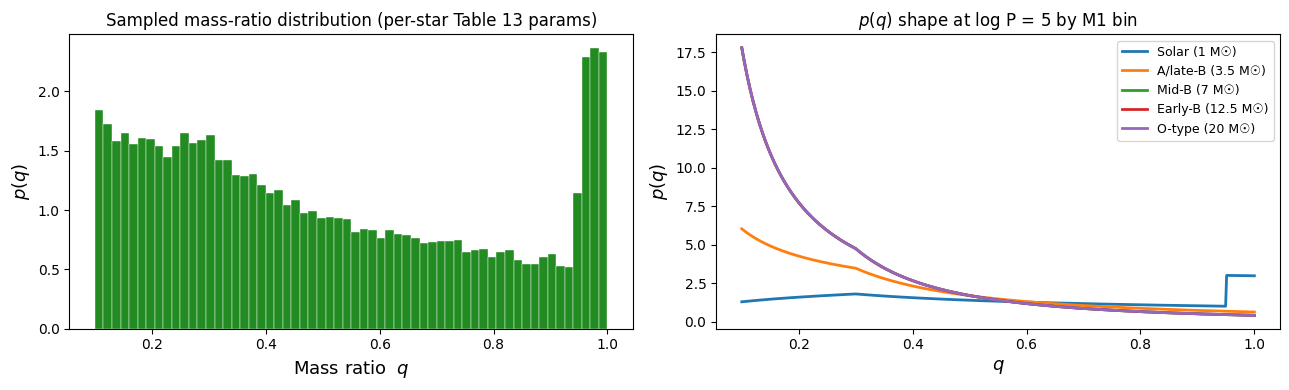

In [21]:
def sample_q_single(gamma_small, gamma_large, F_twin, rng_obj, n_grid=5_000):
    """
    Draw one mass ratio via inverse-CDF for a given set of parameters.
    """
    q_grid = np.linspace(0.1, 1.0, n_grid)
    p_grid = mass_distribution(q_grid, gamma_small, gamma_large, F_twin)
    cdf    = np.cumsum(p_grid); cdf /= cdf[-1]
    return float(np.interp(rng_obj.uniform(), cdf, q_grid))


# Per-star parameters from Table 13 bilinear interpolation
gs = get_gamma_small(M1_bin, logP)
gl = get_gamma_large(M1_bin, logP)
ft = get_F_twin(M1_bin, logP)

# Draw q for each binary — vectorised by grouping into parameter clusters
print("Drawing mass ratios (per-star Table 13 parameters)...")
q = np.array([
    sample_q_single(gs[k], gl[k], ft[k], rng)
    for k in range(len(M1_bin))
])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(q, bins=60, color='forestgreen', edgecolor='white', lw=0.3,
             density=True)
axes[0].set_xlabel(r'Mass ratio  $q$', fontsize=13)
axes[0].set_ylabel(r'$p(q)$', fontsize=13)
axes[0].set_title('Sampled mass-ratio distribution (per-star Table 13 params)',
                  fontsize=12)

# Show how the PDF shape shifts with M1 bin at log P = 5
q_arr = np.linspace(0.1, 1.0, 500)
m_examples = [1.0, 3.5, 7.0, 12.5, 20.0]
labels_ex   = ['Solar (1 M☉)', 'A/late-B (3.5 M☉)', 'Mid-B (7 M☉)',
                'Early-B (12.5 M☉)', 'O-type (20 M☉)']
for m, lbl in zip(m_examples, labels_ex):
    gs_ex = get_gamma_small([m], [5.0])[0]
    gl_ex = get_gamma_large([m], [5.0])[0]
    ft_ex = get_F_twin([m],     [5.0])[0]
    axes[1].plot(q_arr, mass_distribution(q_arr, gs_ex, gl_ex, ft_ex),
                 lw=2, label=lbl)
axes[1].set_xlabel(r'$q$', fontsize=13)
axes[1].set_ylabel(r'$p(q)$', fontsize=13)
axes[1].set_title(r'$p(q)$ shape at log P = 5 by M1 bin', fontsize=12)
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.show()



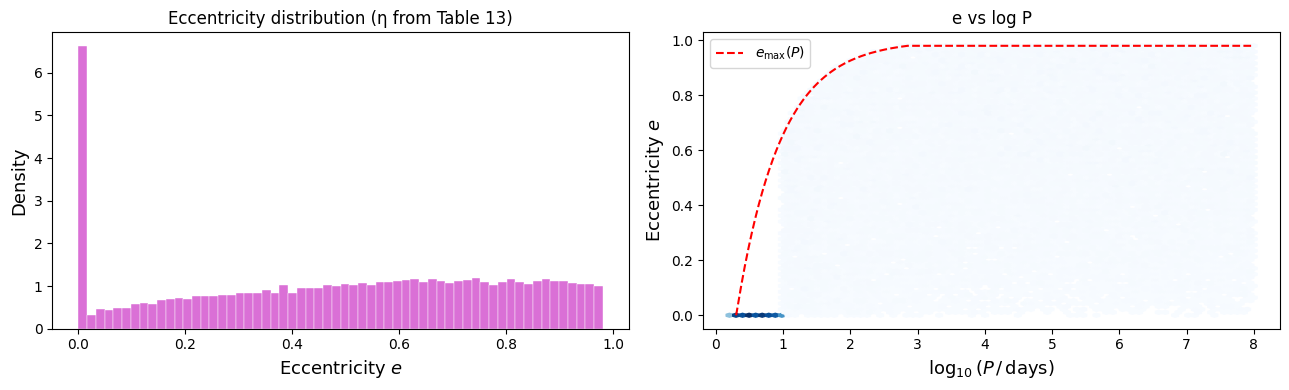

In [26]:
def ecc_max(P_days):
    """
    Maximum eccentricity before Roche lobe overflow at periastron.
    Moe & Di Stefano (2017) Eq. (3).
    """
    P = np.asarray(P_days, dtype=float)
    return np.clip(np.where(P <= 2.0, 0.0, 1.0 - (P / 2.0) ** (-2.0 / 3.0)),
                   0.0, 0.98)


def sample_eccentricity(M1_arr, P_days, rng_obj):
    """
    Draw eccentricities using per-star eta from Table 13.
    p(e) ∝ e^η,  0 ≤ e ≤ e_max(P)
    Short-period binaries (log P < 1, i.e. P < 10 d) are circularised.
    Inverse CDF: e = (u * e_max^(η+1))^(1/(η+1))
    """
    P_days = np.asarray(P_days, dtype=float)
    M1_arr = np.asarray(M1_arr, dtype=float)
    logP = np.log10(P_days)
    e_max_v = ecc_max(P_days)
    eta_v = get_eta(M1_arr, logP)  # per-star from Table 13

    u = rng_obj.uniform(0, 1, len(P_days))
    e_out = np.zeros(len(P_days))
    mask = (logP >= 1.0) & (e_max_v > 0)
    em = e_max_v[mask]
    et = eta_v[mask]
    e_out[mask] = (u[mask] * em ** (et + 1)) ** (1.0 / (et + 1))
    return e_out


e = sample_eccentricity(M1_bin, 10**logP, rng)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(e, bins=60, color='orchid', edgecolor='white', lw=0.3,
             density=True)
axes[0].set_xlabel('Eccentricity $e$', fontsize=13)
axes[0].set_ylabel('Density', fontsize=13)
axes[0].set_title('Eccentricity distribution (η from Table 13)', fontsize=12)

axes[1].hexbin(logP, e, gridsize=80, cmap='Blues', mincnt=1)
e_max_arr = ecc_max(10 ** np.linspace(0.3, 8, 300))
axes[1].plot(np.linspace(0.3, 8, 300), e_max_arr,
             'r--', lw=1.5, label=r'$e_\mathrm{max}(P)$')
axes[1].set_xlabel(r'$\log_{10}(P\,/\,\mathrm{days})$', fontsize=13)
axes[1].set_ylabel('Eccentricity $e$', fontsize=13)
axes[1].set_title('e vs log P', fontsize=12)
axes[1].legend()
plt.tight_layout()
plt.show()


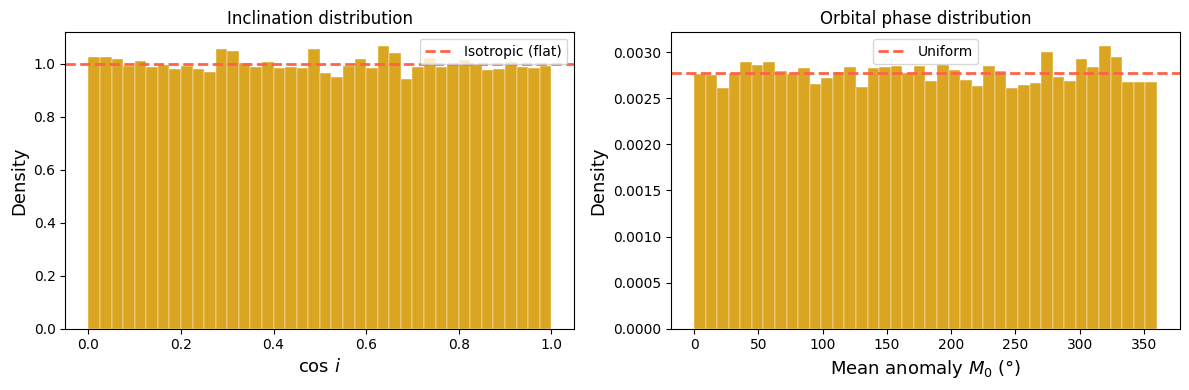

In [27]:
# Orientation and binary phase assumed isotropic

def sample_orientation(n, rng_obj):
    """
    Draw isotropic orientations and random orbital phase.
    Returns (i, omega, Omega, M0) all in degrees.
    """
    cosi = rng_obj.uniform(0, 1, n)
    i = np.degrees(np.arccos(cosi))  # inclination [0,90°]
    omega = rng_obj.uniform(0, 360, n)  # arg of periastron
    Omega = rng_obj.uniform(0, 360, n)  # longitude of ascending node
    M0 = rng_obj.uniform(0, 360, n)  # mean anomaly / orbital phase
    return i, omega, Omega, M0


i, omega, Omega, M0 = sample_orientation(len(M1_bin), rng)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(np.cos(np.radians(i)), bins=40, color='goldenrod',
             edgecolor='white', lw=0.3, density=True)
axes[0].axhline(1.0, color='tomato', lw=2, ls='--', label='Isotropic (flat)')
axes[0].set_xlabel(r'$\cos\,i$', fontsize=13)
axes[0].set_ylabel('Density', fontsize=13)
axes[0].set_title('Inclination distribution', fontsize=12)
axes[0].legend()

axes[1].hist(M0, bins=40, color='goldenrod', edgecolor='white', lw=0.3, density=True)
axes[1].axhline(1 / 360, color='tomato', lw=2, ls='--', label='Uniform')
axes[1].set_xlabel(r'Mean anomaly $M_0$ (°)', fontsize=13)
axes[1].set_ylabel('Density', fontsize=13)
axes[1].set_title('Orbital phase distribution', fontsize=12)
axes[1].legend()
plt.tight_layout();
plt.show()


In [28]:
# combine all in a df
df_synthetic = pd.DataFrame({
    'M1':    M1_bin,
    'P':     10**logP,
    'logP':  logP,
    'q':     q,
    'e':     e,
    'i':     i,
    'omega': omega,
    'Omega': Omega,
    'M0':    M0,
    'e_max': ecc_max(10**logP),
})

print(df_synthetic.describe().round(3))
print(f"\nTotal synthetic binaries: {len(df_synthetic):,}")


              M1             P       logP          q          e          i  \
count  32236.000  3.223600e+04  32236.000  32236.000  32236.000  32236.000   
mean       2.398  5.604223e+06      4.089      0.498      0.497     57.397   
std        3.079  1.583815e+07      2.259      0.281      0.299     21.535   
min        0.800  1.585000e+00      0.200      0.100      0.000      0.293   
25%        1.014  1.323390e+02      2.122      0.255      0.254     41.541   
50%        1.416  1.229767e+04      4.090      0.438      0.527     60.146   
75%        2.427  1.094332e+06      6.039      0.731      0.750     75.543   
max       39.789  9.990727e+07      8.000      1.000      0.980     90.000   

           omega      Omega         M0      e_max  
count  32236.000  32236.000  32236.000  32236.000  
mean     180.962    180.212    180.135      0.890  
std      103.668    103.608    103.942      0.210  
min        0.003      0.002      0.002      0.000  
25%       91.689     90.441     89.59

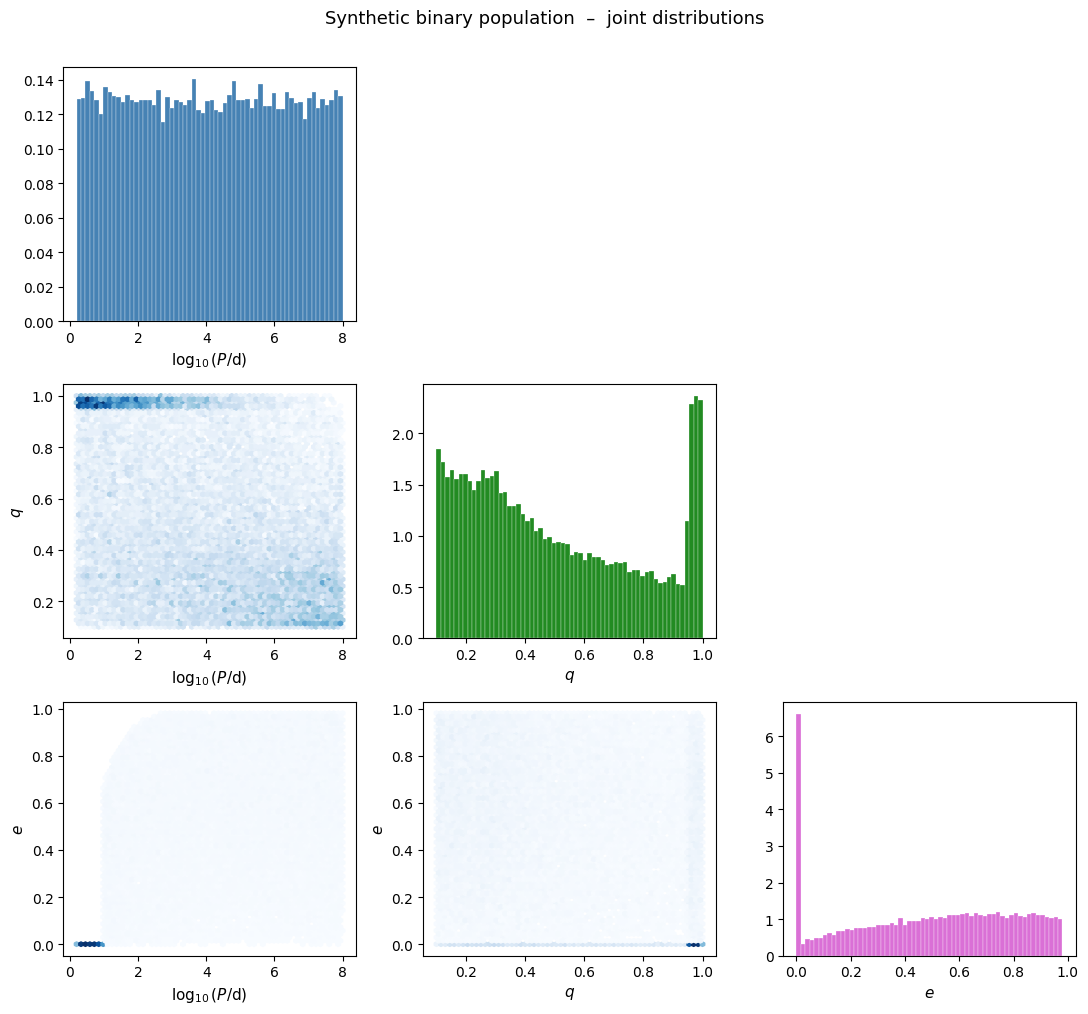

In [29]:
# Plot joint distributions

fig, axes = plt.subplots(3, 3, figsize=(11, 10))
params = ['logP', 'q', 'e']
labels = [r'$\log_{10}(P/\mathrm{d})$', r'$q$', r'$e$']
colours = ['steelblue', 'forestgreen', 'orchid']

for r in range(3):
    for c in range(3):
        ax = axes[r, c]
        if c > r:
            ax.set_visible(False);
            continue
        if c == r:
            ax.hist(df_synthetic[params[r]], bins=60,
                    color=colours[r], edgecolor='white', lw=0.2, density=True)
            ax.set_xlabel(labels[r], fontsize=11)
        else:
            ax.hexbin(df_synthetic[params[c]], df_synthetic[params[r]],
                      gridsize=60, cmap='Blues', mincnt=1)
            ax.set_xlabel(labels[c], fontsize=11)
            ax.set_ylabel(labels[r], fontsize=11)

fig.suptitle('Synthetic binary population  –  joint distributions', fontsize=13, y=1.01)
plt.tight_layout();
plt.show()


## Apply observational constraints
*To be implemented:* Filter the synthetic population to match the detection limits of the ORB6 and SB9 catalogues, then compare the observed distributions with the bias-corrected intrinsic ones.

Typical constraints:
- **SB9** (spectroscopic): detects binaries with K₁ > threshold;   biased towards short P and large q
- **ORB6** (visual orbits): biased against large e (computational   selection; Tokovinin & Kiyaeva 2016); requires resolved separation

